# Fase 4 - Análisis Exploratorio de Datos (EDA) y Visualizaciones
## Proyecto: HumanBehaviorAI - Detección de Bots en Twitter

En este avance se realiza el análisis exploratorio de datos (EDA) y las visualizaciones a partir del archivo `bot_detection_procesado.csv`, el cual fue generado luego del proceso de limpieza y procesamiento de datos realizado en las fases anteriores.

**Objetivo:** entender la estructura del dataset, revisar la calidad de los datos y explorar visualmente las variables más relevantes para la detección de bots.

## 1. Importar librerías

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de estilo para los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Carga de datos

Se carga el archivo `bot_detection_procesado.csv`, que ya cuenta con las columnas generadas durante la limpieza y el procesamiento (variables de fecha, ratios, banderas, etc.).

Con la nueva estructura de carpetas del proyecto, el notebook vive en `..\notebooks` y los datos procesados están en `..\data\processed`, por lo que se usa una ruta relativa hacia esa carpeta.

In [14]:
ruta_datos = os.path.join("..", "data", "processed", "bot_detection_procesado.csv")
df = pd.read_csv(ruta_datos)

# Dimensiones del dataset
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (50000, 30)


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,...,es_fin_de_semana,antiguedad_dias,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags,alta_actividad_pocos_seguidores,no_verif_alto_engagement,activo_madrugada,score_sospecha
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,...,0,1114,0,83,12,0,1,0,0,1
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,...,1,186,2,77,10,1,0,0,1,1
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,...,0,296,2,61,10,1,0,0,1,1
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,...,1,654,4,49,7,1,0,0,0,0
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,...,0,1142,2,29,6,1,0,0,0,0


## 3. Información general del dataset

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          50000 non-null  int64  
 1   Username                         50000 non-null  str    
 2   Tweet                            50000 non-null  str    
 3   Retweet Count                    50000 non-null  int64  
 4   Mention Count                    50000 non-null  int64  
 5   Follower Count                   50000 non-null  int64  
 6   Verified                         50000 non-null  bool   
 7   Bot Label                        50000 non-null  int64  
 8   Location                         50000 non-null  str    
 9   Created At                       50000 non-null  str    
 10  Hashtags                         50000 non-null  str    
 11  anio_creacion                    50000 non-null  int64  
 12  mes_creacion                 

In [16]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,User ID,Retweet Count,Mention Count,Follower Count,Bot Label,anio_creacion,mes_creacion,hora_creacion,dia_semana,engagement_ratio,...,es_fin_de_semana,antiguedad_dias,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags,alta_actividad_pocos_seguidores,no_verif_alto_engagement,activo_madrugada,score_sospecha
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000
mean,548890.680540,50.00560,2.513760,4988.602380,0.500360,2021.239780,6.073360,11.501060,3.011720,0.050133,...,0.29144,623.570160,2.500260,62.627340,9.571200,0.833180,0.06226,0.050020,0.251240,0.36352
std,259756.681425,29.18116,1.708563,2878.742898,0.500005,1.006849,3.465744,6.942187,2.004471,0.807473,...,0.45443,360.836316,1.709368,16.471543,2.329463,0.372819,0.24163,0.217988,0.433731,0.57510
min,100025.000000,0.00000,0.000000,0.000000,0.000000,2020.000000,1.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,23.000000,6.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,323524.250000,25.00000,1.000000,2487.750000,0.000000,2020.000000,3.000000,5.000000,1.000000,0.005500,...,0.00000,312.000000,1.000000,49.000000,8.000000,1.000000,0.00000,0.000000,0.000000,0.00000
50%,548147.000000,50.00000,3.000000,4991.500000,1.000000,2021.000000,6.000000,12.000000,3.000000,0.010500,...,0.00000,621.000000,2.000000,62.000000,10.000000,1.000000,0.00000,0.000000,0.000000,0.00000
75%,772983.000000,75.00000,4.000000,7471.000000,1.000000,2022.000000,9.000000,18.000000,5.000000,0.021100,...,1.00000,938.000000,4.000000,76.000000,12.000000,1.000000,0.00000,0.000000,1.000000,1.00000
max,999995.000000,100.00000,5.000000,10000.000000,1.000000,2023.000000,12.000000,23.000000,6.000000,102.000000,...,1.00000,1246.000000,5.000000,118.000000,14.000000,1.000000,1.00000,1.000000,1.000000,3.00000


## 4. Revisión de calidad de datos

Se valida si existen valores nulos o filas duplicadas. Esto sirve para confirmar que la limpieza previa fue efectiva.

In [17]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nCantidad de filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
User ID                            0
Username                           0
Tweet                              0
Retweet Count                      0
Mention Count                      0
Follower Count                     0
Verified                           0
Bot Label                          0
Location                           0
Created At                         0
Hashtags                           0
anio_creacion                      0
mes_creacion                       0
hora_creacion                      0
dia_semana                         0
engagement_ratio                   0
actividad_total                    0
ratio_retweet_mencion              0
verificado_int                     0
franja_horaria                     0
es_fin_de_semana                   0
antiguedad_dias                    0
cantidad_hashtags                  0
largo_tweet                        0
palabras_tweet                     0
usa_hashtags                       0
alta_activi

## 5. Distribución de la variable objetivo (Bot Label)

`Bot Label` indica si la cuenta fue clasificada como bot (1) o humano (0). Es importante ver si las clases están balanceadas.

Bot Label
1    25018
0    24982
Name: count, dtype: int64


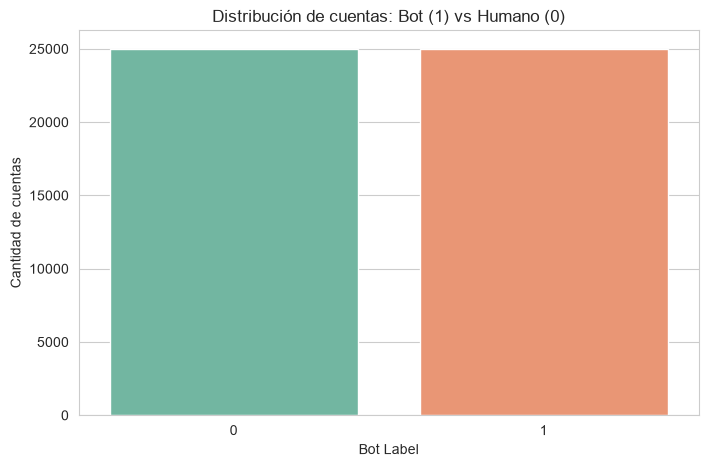

In [18]:
conteo_bot = df["Bot Label"].value_counts()
print(conteo_bot)

plt.figure()
sns.countplot(data=df, x="Bot Label", hue="Bot Label", palette="Set2", legend=False)
plt.title("Distribución de cuentas: Bot (1) vs Humano (0)")
plt.xlabel("Bot Label")
plt.ylabel("Cantidad de cuentas")
plt.show()

## 6. Relación entre verificación de cuenta y comportamiento bot

Se observa si las cuentas verificadas tienden a ser menos identificadas como bots.

Bot Label      0      1
Verified               
False      12456  12540
True       12526  12478


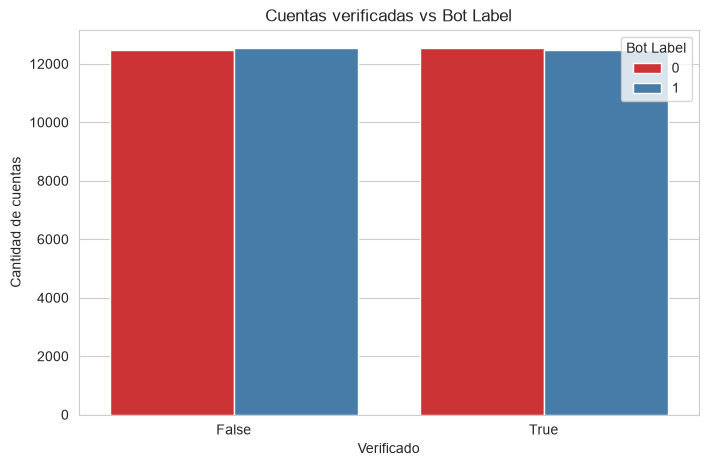

In [19]:
tabla_verif = pd.crosstab(df["Verified"], df["Bot Label"])
print(tabla_verif)

plt.figure()
sns.countplot(data=df, x="Verified", hue="Bot Label", palette="Set1")
plt.title("Cuentas verificadas vs Bot Label")
plt.xlabel("Verificado")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 7. Distribución de la cantidad de seguidores (Follower Count)

Se revisa cómo se distribuye el número de seguidores y si existen diferencias entre bots y humanos.

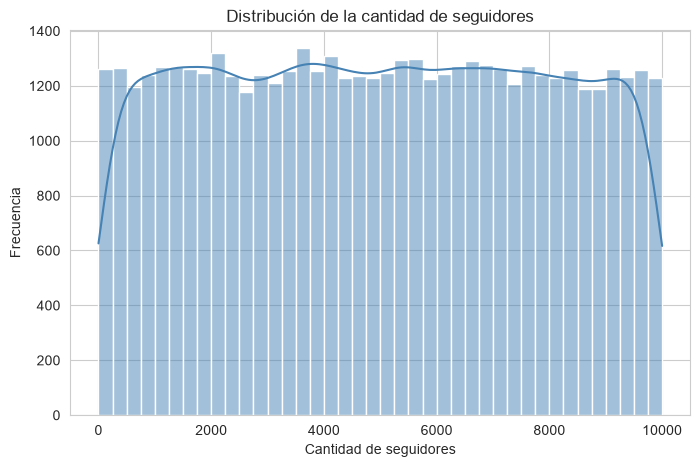

In [20]:
plt.figure()
sns.histplot(data=df, x="Follower Count", bins=40, kde=True, color="steelblue")
plt.title("Distribución de la cantidad de seguidores")
plt.xlabel("Cantidad de seguidores")
plt.ylabel("Frecuencia")
plt.show()

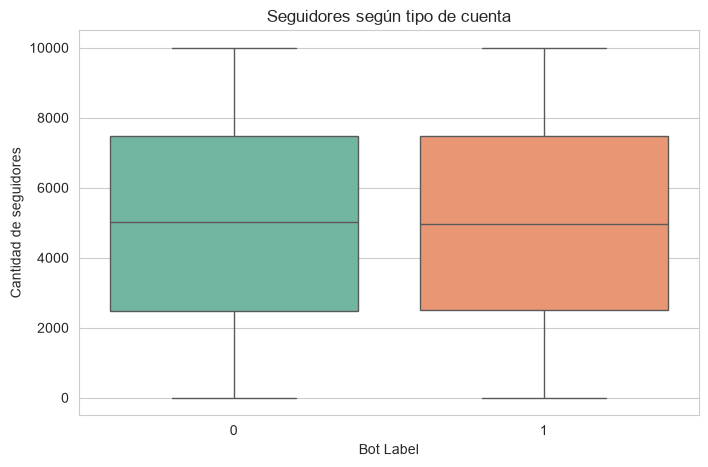

In [21]:
plt.figure()
sns.boxplot(data=df, x="Bot Label", hue="Bot Label", y="Follower Count", palette="Set2", legend=False)
plt.title("Seguidores según tipo de cuenta")
plt.xlabel("Bot Label")
plt.ylabel("Cantidad de seguidores")
plt.show()

## 8. Relación entre actividad y engagement

Se analiza la variable `engagement_ratio`, generada en el procesamiento, para ver si los bots muestran patrones distintos de interacción.

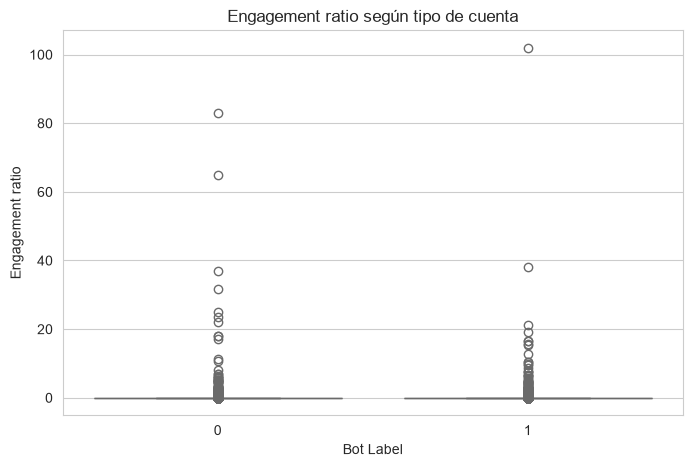

In [22]:
plt.figure()
sns.boxplot(data=df, x="Bot Label", hue="Bot Label", y="engagement_ratio", palette="Set3", legend=False)
plt.title("Engagement ratio según tipo de cuenta")
plt.xlabel("Bot Label")
plt.ylabel("Engagement ratio")
plt.show()

## 9. Actividad según franja horaria

Se revisa en qué franja horaria (madrugada, mañana, tarde, noche) se concentra la actividad de bots y humanos.

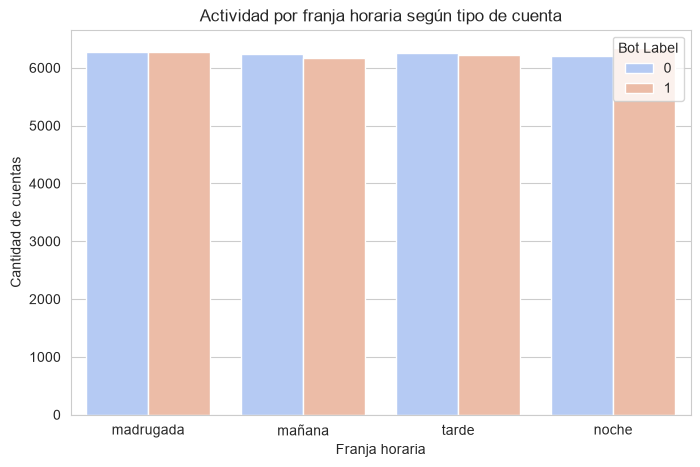

In [23]:
plt.figure()
sns.countplot(data=df, x="franja_horaria", hue="Bot Label", palette="coolwarm",
              order=["madrugada", "mañana", "tarde", "noche"])
plt.title("Actividad por franja horaria según tipo de cuenta")
plt.xlabel("Franja horaria")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 10. Correlación entre variables numéricas

Se construye una matriz de correlación para identificar qué variables numéricas están más relacionadas entre sí y con la variable objetivo.

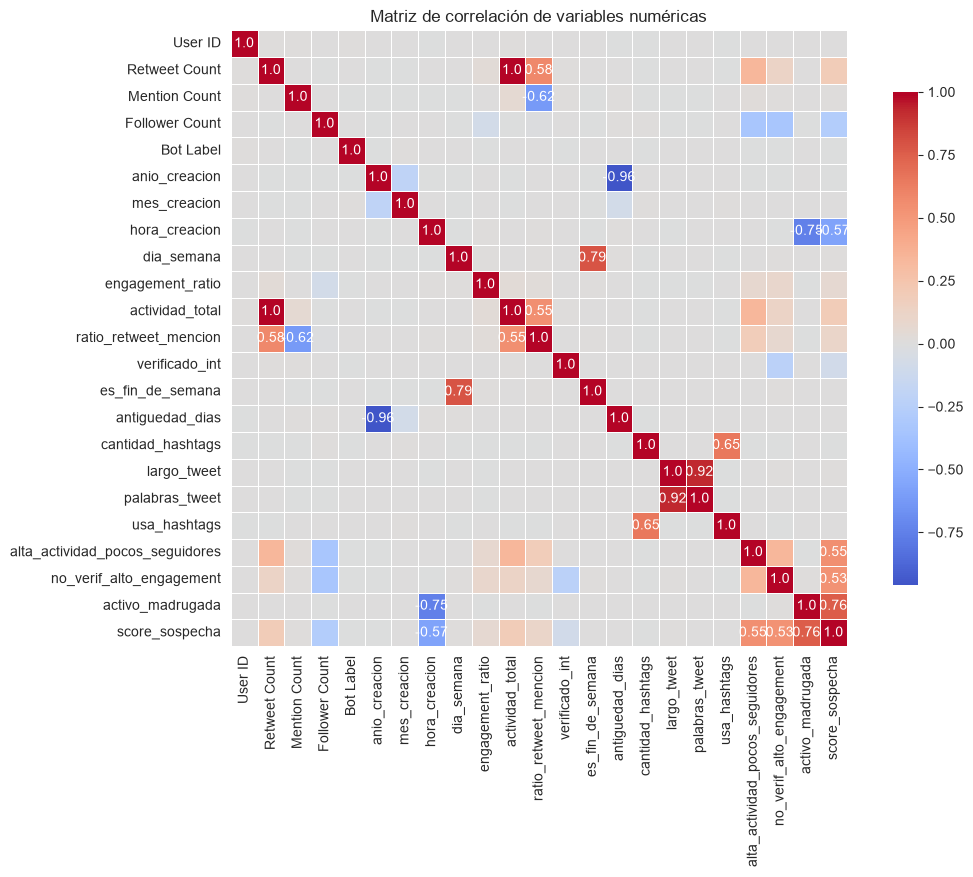

In [24]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
matriz_corr = df[columnas_numericas].corr()

# Umbral para considerar una correlación como "fuerte"
umbral = 0.5

anotaciones = matriz_corr.round(2).astype(str)
anotaciones = anotaciones.where(matriz_corr.abs() >= umbral, "")

plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_corr,
    cmap="coolwarm",
    center=0,
    annot=anotaciones,
    fmt="",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación de variables numéricas")
plt.savefig("correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Score de sospecha vs Bot Label

`score_sospecha` es una variable creada en el procesamiento que combina varias señales de comportamiento sospechoso. Se valida qué tan bien se relaciona con la etiqueta real de bot.

Cada bandera vale 1 si se cumple o 0 si no. Entonces score_sospecha va de 0 a 3 porque son 3 banderas sumadas:

- 0 = *la cuenta **no** cumple ninguna señal sospechosa*

- 1 = *cumple **una** señal sospechosa*

- 2 = *cumple **dos** señales sospechosas*

- 3 = *cumple las **tres** señales sospechosas*

Bot Label           0      1
score_sospecha              
0               16971  17065
1                7032   6992
2                 847    821
3                 132    140


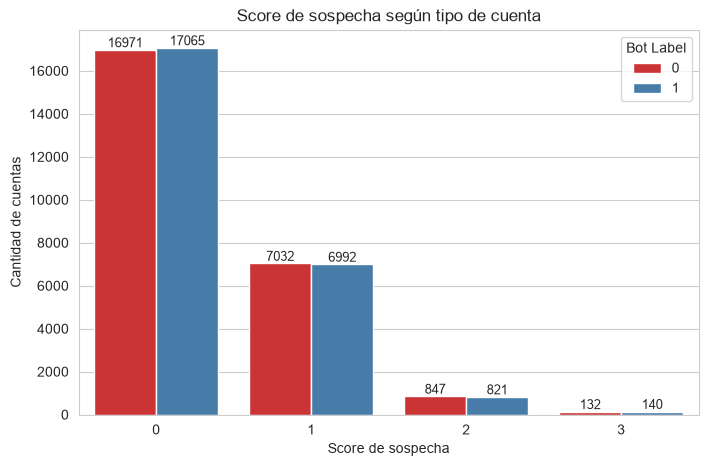

In [25]:
tabla_score = pd.crosstab(df["score_sospecha"], df["Bot Label"])
print(tabla_score)

plt.figure()
ax = sns.countplot(data=df, x="score_sospecha", hue="Bot Label", palette="Set1")

# Agrega el valor exacto encima de cada barra
for contenedor in ax.containers:
    ax.bar_label(contenedor, fontsize=9)

plt.title("Score de sospecha según tipo de cuenta")
plt.xlabel("Score de sospecha")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 12. Conclusiones preliminares

- El dataset procesado no presenta valores nulos ni duplicados, lo cual confirma que la limpieza previa fue efectiva.
- La distribución de la variable `Bot Label` permite ver si el dataset está balanceado entre bots y humanos.
- Variables como `engagement_ratio`, `Follower Count` y `score_sospecha` muestran diferencias visibles entre cuentas bot y humanas, lo que sugiere que pueden ser útiles para un futuro modelo de clasificación.
- La franja horaria de actividad también aporta información relevante sobre el comportamiento de las cuentas.

Este análisis sirve como base para la siguiente fase del proyecto, donde se plantearía el modelado o clasificación de cuentas bot.

# 3. Hallazgos importantes

Revisando con más detalle los datos de las secciones anteriores, encontramos algo que vale la pena aclarar sobre lo que se concluye en la sección 12: al final no logramos encontrar ninguna variable que realmente separe las cuentas bot de las humanas. A continuación se muestran los cálculos que respaldan esta conclusión.

In [26]:
# Correlación exacta de cada variable con Bot Label, sin aplicar ningún umbral
columnas_num = df.select_dtypes(include=["int64", "float64", "bool"]).columns
corr_bot = df[columnas_num].corr(numeric_only=True)["Bot Label"].drop("Bot Label")
corr_bot = corr_bot.sort_values(key=abs, ascending=False)

print("Correlación de cada variable con Bot Label (ordenado por fuerza):")
print(corr_bot.round(4))
print(f"\nCorrelación más alta encontrada: {corr_bot.abs().max():.4f}")

Correlación de cada variable con Bot Label (ordenado por fuerza):
Mention Count                     -0.0069
mes_creacion                       0.0061
User ID                            0.0061
no_verif_alto_engagement          -0.0043
ratio_retweet_mencion              0.0029
cantidad_hashtags                 -0.0029
score_sospecha                    -0.0028
anio_creacion                     -0.0028
verificado_int                    -0.0026
Verified                          -0.0026
hora_creacion                      0.0022
alta_actividad_pocos_seguidores   -0.0021
engagement_ratio                  -0.0020
es_fin_de_semana                   0.0018
dia_semana                        -0.0018
palabras_tweet                    -0.0013
Retweet Count                      0.0012
Follower Count                     0.0012
antiguedad_dias                    0.0010
largo_tweet                        0.0009
actividad_total                    0.0008
usa_hashtags                      -0.0007
activo_mad

**Las variables numéricas parecen generadas al azar.**
En el `describe()` de la sección 3, `Retweet Count` va de 0 a 100 con media 50, y `Follower Count` va de 0 a 10,000 con media casi 5,000. Son justo los números que uno esperaría si esos valores se generaron con un rango aleatorio, no de datos reales de Twitter. Esto se ve todavía más claro en el histograma de `Follower Count` (sección 7), donde la distribución es completamente plana de 0 a 10,000. En una red social real esto no pasa: la mayoría de cuentas tiene pocos seguidores y muy pocas tienen números altos, no una cantidad pareja en todo el rango.

**El mapa de correlación también lo confirma.**
En la matriz de correlación (sección 10), la fila de `Bot Label` queda completamente en blanco porque no llega al umbral de 0.5 que se usó en el gráfico. Al calcular las correlaciones exactas sin ese filtro (celda anterior), la más alta que salió fue de 0.0069, con Mention Count. En estadística normalmente se considera que una correlación empieza a ser notable a partir de 0.1 o 0.2, así que 0.0069 en la práctica es como no tener ninguna relación.

In [27]:
# Comparación de medias entre cuentas bot y humanas
variables_clave = ["Retweet Count", "Mention Count", "Follower Count",
                    "engagement_ratio", "actividad_total", "score_sospecha"]

medias = df.groupby("Bot Label")[variables_clave].mean()
medias.index = ["Humano (0)", "Bot (1)"]

diferencia_pct = ((medias.loc["Bot (1)"] - medias.loc["Humano (0)"])
                   / medias.loc["Humano (0)"] * 100).round(2)

print("Medias por tipo de cuenta:")
display(medias.round(3))
print("\nDiferencia porcentual (Bot vs Humano):")
print(diferencia_pct)

Medias por tipo de cuenta:


,Retweet Count,Mention Count,Follower Count,engagement_ratio,actividad_total,score_sospecha
Humano (0),49.969,2.526,4985.256,0.052,52.495,0.365
Bot (1),50.042,2.502,4991.944,0.049,52.544,0.362



Diferencia porcentual (Bot vs Humano):
Retweet Count       0.15
Mention Count      -0.94
Follower Count      0.13
engagement_ratio   -6.26
actividad_total     0.09
score_sospecha     -0.89
dtype: float64


Ninguna variable por separado muestra diferencia real.
Los boxplots de `Follower Count` y `engagement_ratio` (secciones 7-8) se ven casi iguales entre bot y humano. La tabla de arriba lo confirma con números: las diferencias son menores al 1% en casi todos los casos, y la más alta (`engagement_ratio`) apenas llega a -6.26%, algo demasiado pequeño para que un modelo lo pueda aprovechar de forma confiable.

La tabla de verificación (sección 6) también da proporciones casi 50/50 en las cuatro combinaciones. Y la actividad por franja horaria (sección 9) tampoco cambia entre bots y humanos, ni siquiera en la madrugada, que era justo el patrón que se esperaba encontrar en bots según lo planteado en la Fase 3.

El score de sospecha tampoco funciona.
El `score_sospecha` (sección 11) combina tres señales que en teoría deberían indicar comportamiento de bot, pero al compararlo entre bots y humanos las cantidades son casi idénticas en los cuatro niveles. Incluso en el nivel más alto (score = 3), hay 140 bots contra 132 humanos, básicamente empatado.

In [28]:
# Revisar si las ubicaciones con "100% bot" son un patrón real o solo casualidad
conteo_location = df["Location"].value_counts()
pct_bot_location = df.groupby("Location")["Bot Label"].mean()

resumen_location = pd.DataFrame({
    "cantidad_registros": conteo_location,
    "pct_bot": (pct_bot_location * 100).round(1)
}).sort_values("pct_bot", ascending=False)

print("Ubicaciones con mayor % de bots (top 10):")
print(resumen_location.head(10))

print("\nCantidad de ubicaciones con 100% de bots:", (resumen_location["pct_bot"] == 100).sum())
print("De esas, cuántas tienen 5 registros o menos:",
      ((resumen_location["pct_bot"] == 100) & (resumen_location["cantidad_registros"] <= 5)).sum())

Ubicaciones con mayor % de bots (top 10):
                cantidad_registros  pct_bot
Location                                   
Zunigaberg                       1    100.0
Zoeside                          1    100.0
Aaronborough                     1    100.0
Zimmermanville                   2    100.0
Zimmermanstad                    1    100.0
Zacharybury                      1    100.0
Zacharyburgh                     1    100.0
Yvonneton                        1    100.0
Yvonneport                       1    100.0
Yvonneberg                       1    100.0

Cantidad de ubicaciones con 100% de bots: 9557
De esas, cuántas tienen 5 registros o menos: 9545


Viendo `engagement_ratio` sin los valores extremos.
En la sección 8, el boxplot de engagement_ratio se veía aplastado por unos pocos valores muy altos. Al quitar esos casos extremos (cuentas con engagement_ratio,  mayor a 1, que son una minoría) y graficar la distribución del resto, se puede ver con claridad que las curvas de bot y humano quedan prácticamente encimadas. Esto confirma, ahora sí de forma visual y no solo con el número de la media, que tampoco en el rango normal de esta variable hay una diferencia real entre ambos grupos.

# 4. Explicación de patrones encontrados

Lo más importante que encontramos en esta fase no es un patrón que diferencie bots de humanos, sino que no existe tal patrón en este dataset, y creemos que eso tiene una explicación razonable, no significa que algo se hizo mal en fases anteriores.

**¿Por qué no aparece ninguna diferencia?**
Todo apunta a que este dataset de Kaggle fue armado de forma sintética, es decir, que la etiqueta de bot se puso sin conectarla realmente con los números de actividad (retweets, seguidores, menciones, horarios). Si el comportamiento de los bots fuera real, uno esperaría ver algunas de las señales típicas que se plantearon en la Fase 1, por ejemplo, cuentas con poca gente siguiéndolas pero mucha actividad, o publicaciones concentradas en ciertas horas. Nada de eso aparece aquí, y la distribución tan pareja de `Follower Count` refuerza la idea de que esos números se generaron aleatoriamente.

**Sobre lo que se concluyó en la sección 12:**
Ahí se menciona que `engagement_ratio`, `Follower Count` y `score_sospecha` muestran diferencias visibles entre bots y humanos, pero revisando los gráficos con más calma esa diferencia no se sostiene tanto. En el caso de `Follower Count`, los dos boxplots son prácticamente idénticos en mediana y rango (la diferencia real entre las medias es de 0.13%, o sea casi nada). En el caso de `engagement_ratio`, lo que pasa es que el gráfico tiene unos pocos valores extremos (cuentas con casi ningún seguidor, que hacen que el ratio se dispare matemáticamente) y eso hace que el resto de los datos se vea aplastado cerca de cero, dando la impresión de que hay algo raro pasando cuando en realidad, al quitar esos extremos, las distribuciones de bot y humano quedan prácticamente iguales. Algo parecido pasa con `Location`: hay miles de ciudades con 100% de bots, pero casi todas tienen 1 o 2 registros nada más, así que ese porcentaje no significa nada real. Son dos ejemplos de por qué conviene revisar los números exactos y no quedarse solo con lo que "se ve" a primera vista en un gráfico o una tabla.

**Qué implica esto para el resto de la fase.**
Por esta razón, es de esperar que el modelo de IA que se desarrolle en la siguiente sección tenga un desempeño limitado, no por errores en su construcción, sino por esta limitación estructural de los datos. Esto encaja con lo que dice el enunciado del proyecto: no se evalúa solo la precisión, sino la interpretación y el razonamiento detrás. Por eso, más que buscar maquillar el resultado, tiene más sentido dejar clara esta explicación desde el análisis exploratorio.